In [7]:
import pathlib
import numpy as np

local = pathlib.Path.cwd()
mlmodel = None
target = np.array([392, 518])

def mlpackage():
    global Image
    from PIL import Image
    from pillow_heif import register_heif_opener
    register_heif_opener()

    import coremltools as ct
    return ct.models.MLModel('DepthAnythingV2SmallF16.mlpackage')

def fs(pth, npy = None):
    global mlmodel
    if type(npy) is str:
        npy = pathlib.Path(npy)
    if npy is not None and npy.exists():
        return np.load(npy)
    if mlmodel is None:
        mlmodel = mlpackage()
    im = Image.open(pth)
    size = np.array(im.size)
    scaled = np.int32(np.max(target / size) * size)
    im_s = im.resize(scaled)
    origin = (scaled - target[::-1]) // 2
    im_t = im_s.crop(np.concat((origin, origin + target[::-1])))
    out = np.array(mlmodel.predict({"image": im_t})['depth'])
    if npy is not None:
        np.save(npy, out)
    return out

im4 = fs(local / "IMG_0004.HEIC", local / "out4.npy")
im5 = fs(local / "IMG_0005.HEIC", local / "out5.npy")

In [177]:
import matplotlib.pyplot as plt

In [221]:
from functools import cached_property
import sympy as sy

class SphereRaster:
    t0, t1 = target // 2
    offset = sy.Rational(1, 10)
    def __init__(self, r=np.min(target) // 5):
        self.r = r
        self.a, self.b = self.dim = sy.symbols('a b')

    @cached_property
    def rescale(self):
        return sy.Rational(4, 5 * self.r)

    @cached_property
    def im(self):
        out = np.zeros(target)
        c1, c0 = np.meshgrid(*map(np.arange, target[::-1]))
        d2 = (self.t0 - c0) ** 2 + (self.t1 - c1) ** 2
        out[d2 < self.r ** 2] = np.sqrt(self.r ** 2 - d2[d2 < self.r ** 2])
        out *= float(self.rescale)
        out[d2 < self.r ** 2] += float(self.offset)
        return out

    @cached_property
    def approx(self):
        return adjust(self.im)
 
class Concave(SphereRaster):
    @cached_property
    def im(self):
        arr = super().im
        return np.where(arr < float(self.offset) / 2, arr, 1 - arr)

In [228]:
class Sphere(SphereRaster):
    def sym(self):
        return self.offset + self.rescale * sy.sqrt(
                self.r ** 2 - (self.t0 - self.a) ** 2 - (self.t1 - self.b) ** 2)

    def grad(self):
        expr = self.sym()
        return sy.Matrix([[sy.diff(expr, self.a)], [sy.diff(expr, self.b)]])

    def hessian(self):
        expr = self.grad()
        return sy.Matrix.hstack(sy.diff(expr, self.a), sy.diff(expr, self.b))

    def eigenvalues(self):
        expr = self.hessian()
        tr = expr.trace()
        center = tr / 2
        radius = sy.sqrt(tr ** 2 / 4 - expr.det())
        return sy.Matrix([[center - radius], [center + radius]])

    def sec2(self):
        para, perp = self.eigenvalues()
        return para / perp

    def adjusted(self):
        d0, d1 = d = self.grad()
        return (self.sec2() - 1) / (d0 ** 2 + d1 ** 2) * d

    def at(self, *args):
        return list(zip(self.dim, args))

    def subs(self, a, b):
        return self.adjusted().subs(self.at(a, b))

    def cmp(self, a, b):
        return [i[a, b] for i in self.approx], \
                self.subs(a, b).T.evalf().tolist()[0]

In [229]:
a, b, c, p, w = sy.symbols('a b c p w')
expr = c + sy.sqrt(p ** 2 - a ** 2 - b ** 2) / w

change = [(b, 0)]
f = expr.subs(change)
da = sy.simplify(sy.diff(expr, a).subs(change))
da2 = sy.simplify(sy.diff(expr, a, a).subs(change))
db2 = sy.simplify(sy.diff(expr, b, b).subs(change))

print(sy.simplify((da2 / db2 - 1) / da ** 2))

w**2


In [230]:
from scipy.ndimage import sobel
from typing import Literal

coord = np.stack(np.meshgrid(*map(np.arange, target[::-1]))[::-1], -1)
diag = np.sqrt(np.sum(target ** 2))

def grad(arr):
    return np.stack((sobel(arr, 0), sobel(arr, 1)), -1) / 8

def hessian(partials):
    return np.stack((grad(partials[..., 0]), grad(partials[..., 1])), -1)

def interpolate(continuous: np.ndarray[tuple[int, Literal[2]], np.dtype[np.float64]]):
    out = np.zeros(target)
    floored = np.int32(np.floor(continuous))
    remainder = continuous - floored
    for offset in np.array([[[0, 0]], [[0, 1]], [[1, 0]], [[1, 1]]]):
        filling = floored + offset
        overlap = 1 - offset + (2 * offset - 1) * remainder
        valid = np.all(np.logical_and(filling >= 0, filling < target[None]), axis=1)
        np.add.at(
                out,
                (filling[valid][..., 0], filling[valid][..., 1]),
                overlap[valid][..., 0] * overlap[valid][..., 1])
    return out

def rotated(partials, second):
    norm = np.sqrt(np.sum(partials ** 2, -1, keepdims=True))
    basis0 = np.divide(
            partials, norm, out=np.zeros_like(partials), where=norm != 0)
    basis1 = basis0[..., ::-1] * np.array([[[-1, 1]]])
    basis = np.stack((basis0, basis1), -1)
    inv = basis * np.array([[[[1, -1], [-1, 1]]]])
    return inv @ second @ basis

In [218]:
def normals(partials, t):
    parametric = (coord + partials * t * diag).reshape([-1, 2])
    return interpolate(parametric)

def casts(im, slopes, depth):
    delta = im - depth
    intersection = coord + delta[..., None] * slopes
    return interpolate(intersection[delta > 0].reshape([-1, 2]))

def adjust(arr):
    partials = grad(arr)
    second = hessian(partials)
    eigval, eigvec = np.linalg.eigh(second)
    # λ[0] = ∂∥∂∥ <= ∂⟂∂⟂ = λ[1]
    para, perp = np.min(eigval, -1), np.max(eigval, -1)
    # perp < 0 <-> negative definite <-> convex out-of-the-page/screen
    # the (first) eigenvectors should form a good basis for the gradient
    sec2 = np.divide(para, perp, out=np.ones_like(arr), where=perp != 0)
    # sec ** 2 - 1 = tan ** 2
    coef = (sec2 - 1) / np.sum(partials ** 2, -1)
    return partials * coef[..., None]

In [219]:
from functools import partial

def slide(f, **kw):
    frame = f(kw["valinit"] if "valinit" in kw else 0)

    from matplotlib.widgets import Slider, Button
    fig, ax = plt.subplots()
    out = ax.imshow(frame, vmin=0, vmax=4)
    fig.subplots_adjust(bottom=0.25)

    axt = fig.add_axes([0.1, 0.1, 0.8, 0.03])
    slider = Slider(ax=axt, label='t', **kw)
    def update(val):
        nonlocal frame
        frame = f(slider.val)
        out.set_data(frame)
        fig.canvas.draw_idle()
    slider.on_changed(update)

    plt.show()

def slide0(arr, slopes=None):
    slopes = grad(arr) if slopes is None else slopes
    return slide(partial(normals, slopes), valmin=0, valmax=8, valinit=0)

def slide1(arr, slopes=None, **kw):
    slopes = adjust(arr) if slopes is None else slopes
    defaults = { "valmin": 0, "valmax": 1, "valinit": 0.1 }
    return slide(partial(casts, arr, slopes), **{**defaults, **kw})

https://www.desmos.com/c/h0pkuzhfzh

https://www.desmos.com/3d/9ijh5b7ok9

$m = \frac{\partial\parallel\partial\parallel}{\left(\partial\perp\partial\perp\right)^3}\partial\parallel$ wrt gradient

https://www.desmos.com/3d/pt8citup10

$m = \frac{\frac{\partial\parallel\partial\parallel}{\partial\perp\partial\perp} - 1}{\left\|\left(\partial\parallel\right)\right\|^2}\partial\parallel$

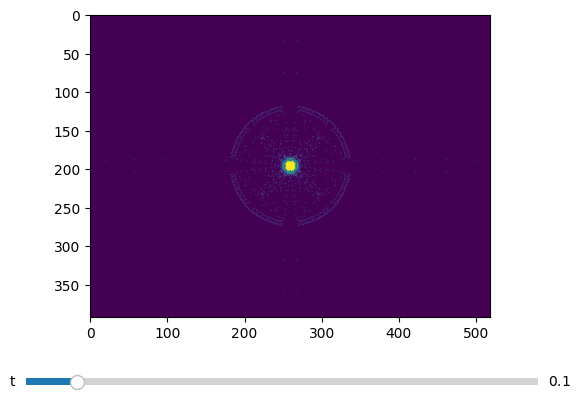

In [220]:
def depth_slices(arr=im5):
    partials = grad(arr)
    second = hessian(partials)
    out = rotated(partials, second)
    concave_down = np.logical_and(np.linalg.det(out) > 0, out[..., 0, 0] < 0)
    sec2 = np.divide(
            out[..., 0, 0], out[..., 1, 1],
            out=2 * np.ones_like(arr), where=concave_down)
    norm = np.sum(partials ** 2, -1)
    coef = np.divide(sec2 - 1, norm, out=np.ones_like(norm), where=norm != 0)
    slopes = partials * coef[..., None]
    slide1(arr, slopes)

if __name__ == "__main__":
    depth_slices(Sphere().im)

The more directions a point is approached from, the better evidence it provides. The magnitude of the cross product of 2 vectors gives the area defined by the parallelogram, which encourages being orthogonal, and is therefore a better conditioned basis.

In [184]:
def basis_metric(rays: np.ndarray[tuple[Literal[2], int], np.dtype[np.float64]]):
    assert rays.shape[0] == 2
    # consider each of the "support rays" along an extra dimension
    expanded = np.vstack((rays, np.eye(rays.shape[1])))
    # svd.U is an orthonormal basis for the column space of expanded
    svd = np.linalg.svd(expanded, full_matrices=False)
    # sub is the unstretched embedding of expanded into one dimension per point
    sub = svd.U.T @ expanded
    # and the absoulte value of the determinant gives the volume formed by the new vectors
    return np.abs(np.linalg.det(sub))

In [185]:
def cis_h(half_turns):
    half_turns = np.array(half_turns) * np.pi
    return np.stack((np.cos(half_turns), np.sin(half_turns)))

In [186]:
basis_metric(cis_h([1 / 5, 1 / 3]))

np.float64(1.7791668546880508)

In [187]:
basis_metric(cis_h([1 / 5, 1 / 4]))

np.float64(1.7391008429221182)

looks alright so far: the behavior still follows the cross product

In [188]:
basis_metric(cis_h([1 / 5, 1 / 3, 5 / 4]))

np.float64(2.0632241121072576)

In [189]:
basis_metric(cis_h([1 / 5, 1 / 3, 1 / 4]))

np.float64(2.0632241121072568)

Intuitively, want the penultimate one to be considered a better basis than the last one. 

the cross product also gives the same result for [1/5, 5/4] as [1/5, 1/4]

side note: I can either subtract off the added volume from the extra dimensions or adjust the stacked diagonal matrix to the magnitudes of the converging rays. I've just been testing with unit vectors out of habit, not clear that they'll end up normalized.

https://navigu.net/#imagenet13m#n02778669/n02778669_5852.jpg

If I half all the angles it works. I feel like there's a clever way to integrate the geometric transformation without going through trig angles. Probably worth trying the naive way first.

In [190]:
def horizon_metric(rays: np.ndarray[tuple[Literal[2], int], np.dtype[np.float64]]):
    assert rays.shape[0] == 2
    halved = np.atan2(*rays[::-1]) / 2
    transformed = np.stack((np.cos(halved), np.sin(halved))) * np.linalg.norm(rays, axis=0, keepdims=True)
    # consider each of the "support rays" along an extra dimension
    expanded = np.vstack((transformed, np.eye(rays.shape[1])))
    # svd.U is an orthonormal basis for the column space of expanded
    svd = np.linalg.svd(expanded, full_matrices=False)
    # sub is the unstretched embedding of expanded into one dimension per point
    sub = svd.U.T @ expanded
    # and the absoulte value of the determinant gives the volume formed by the new vectors
    return np.abs(np.linalg.det(sub)) - 1

In [191]:
horizon_metric(cis_h([1]))

np.float64(0.4142135623730949)

In [192]:
horizon_metric(cis_h([1 / 5, 1 / 3, 1 / 4]))

np.float64(1.0165366814755932)

In [193]:
horizon_metric(cis_h([1 / 5, 1 / 3, 5 / 4]))

np.float64(1.4535758302161375)

I should approximate normal convergence over both depth and time

I've also been meaning to check the effect of FOV. XCode gives `'isCameraIntrinsicMatrixDeliverySupported' is unavailable in visionOS`. The first step in the app setup is going to be tossing the ball so that distances can be calibrated with respect to gravity's acceleration, so it may also end up possible to approximate on the fly.

https://www.apple.com/apple-vision-pro/specs/

apparently 18mm is the 35mm equivalent focal length (the HEIC metadata says the real focal length is 0.5959 mm)

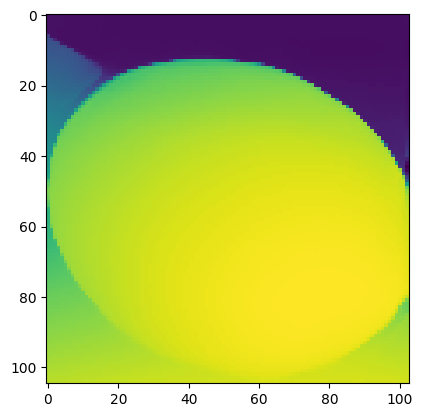

In [236]:
plt.imshow(im5[225:330, 415:])
plt.show()

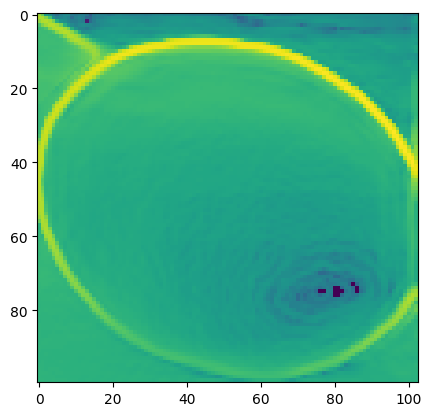

In [267]:
plt.imshow(np.log(np.maximum(1e-6, np.linalg.norm(grad(im5)[230:330, 415:], axis=2))))

It looks like the depth estimation is z position in camera space, not ray-cast distance.

$$\text{Euclidean Distance} = Z \cdot \sqrt{1 + \left(\frac{u - c_x}{f}\right)^2 + \left(\frac{v - c_y}{f}\right)^2}$$
where the pixel coordinates are $(u, v)$ the center of the image is $(c_x, c_y)$ and $f$ is the focal length in pixels

In [247]:
f_px = 18 / 35 * np.linalg.norm(target)
print(f_px)

334.08310343386114


In [251]:
csc = np.sqrt(1 + np.sum(((coord - target[None] / 2) / f_px) ** 2, axis=-1))

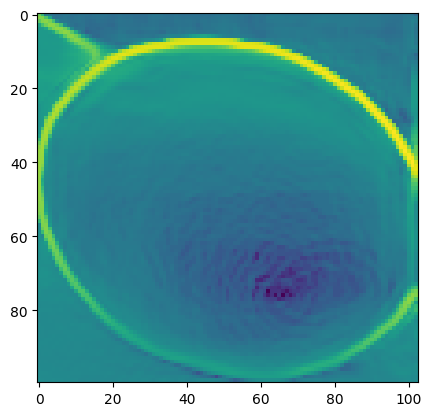

In [266]:
plt.imshow(np.log(np.maximum(1e-6, np.linalg.norm(grad(1 - csc * (1 - im5))[230:330, 415:], axis=2))))

For the first pass, use depth-anything to nominate spherical things. From instance segmentation labels for balls, fine-tune depth-anything to encourage rounder depth maps for spheres. Keep the rest accurate via loss versus the original output for random scenes. Monitor weight changes with and without sphere phase. Check if the FOV correction is still beneficial after fine-tuning.

For the second pass, use a VAE to generate encodings conditioned on a classifier. Input distribution is based on the nomination process versus bounding box labels. Fine-tune it to encourage temporal stability for some of the channels using [video training data](https://research.google.com/youtube8m/) ([teacher model](https://github.com/roboflow/rf-detr), artificially encourage a wide size distribution). Use the stable channels to track objects.

unclear whether to move to colab for bandwidth or linux box for convenience.

once I have the nominated sphere, it might be helpful to use instance segmentation to isolate the pixels to follow for pose estimation. I should share the encoder with the VAE and add a U-net segmentation head

The second pass should be lower frequency and higher certainty than the first pass. Track the ray convergence with and without segmentation mask. Use locality to adjust region of interest. Save frames cropped to be input for the un-calculated second pass for higher fidelity replays. Possibly adjust second pass frequency by proximity to colliders.

The next actual code I should write is testing `horizon_metric`. The whole thing is differentiable (svd?), so I might be able to get away with gradient descent to find extrema in order to replace depth slices.

$$A=\begin{bmatrix}\vdots & \vdots & \ddots & & \\ \vec{u} & \vec{v} & & I_n & \\ \vdots & \vdots & & & \ddots \end{bmatrix}$$

$$A^T A=\begin{bmatrix}\cdots & \vec{u} & \cdots \\ \cdots & \vec{v} & \cdots \\ \ddots & & \\ & I_n & \\ & & \ddots\end{bmatrix} \begin{bmatrix}\vdots & \vdots & \ddots & & \\ \vec{u} & \vec{v} & & I_n & \\ \vdots & \vdots & & & \ddots \end{bmatrix}$$

$$\det A^T A=\begin{vmatrix}\left<\vec{u}, \vec{u}\right> & \left<\vec{u}, \vec{v}\right> & \cdots & \vec{u} & \cdots \\ \left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & \cdots & \vec{v} & \cdots \\ \vdots & \vdots & \ddots & & \\ \vec{u} & \vec{v} & & I_n & \\ \vdots & \vdots & & & \ddots \end{vmatrix}$$

$$
=\left<\vec{u}, \vec{u}\right>\begin{vmatrix}\left<\vec{v}, \vec{v}\right> & \cdots & \vec{v} & \cdots \\ \vdots & \ddots & & \\ \vec{v} & & I_n & \\ \vdots & & & \ddots \end{vmatrix}
-\left<\vec{u}, \vec{v}\right>\begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \cdots & \vec{v} & \cdots \\ \vdots & \ddots & & \\ \vec{u} & & I_n & \\ \vdots & & & \ddots \end{vmatrix}
+u_1 \begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_2 & \cdots & v_n \\ \vdots & \vdots & \cdots & \vec{0} & \cdots \\ \vec{u} & \vec{v} & \ddots & & \\ \vdots & \vdots & & I_{n-1} & \\ \vdots & \vdots & & & \ddots \end{vmatrix}
-u_2 \begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_1 & v_3 & \cdots & v_n \\ \vdots & \vdots & I_1 & \cdots & \vec{0} & \cdots \\ \vdots & \vdots & 0 & \cdots & \vec{0} & \cdots \\ \vec{u} & \vec{v} & \vdots & \ddots & & \\ \vdots & \vdots & \vec{0} & & I_{n-2} & \\ \vdots & \vdots & \vdots & & & \ddots \end{vmatrix}
+\dots
\pm u_n \begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_1 & \cdots & v_{n-1} \\ \vdots & \vdots & \ddots & & \\ \vdots & \vdots & & I_{n-1} & \\ \vec{u} & \vec{v} & & & \ddots \\ \vdots & \vdots & \cdots & \vec{0} & \cdots\end{vmatrix}
$$

$$
\pm u_k \begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_1 & \cdots & v_{k-1} & v_{k+1} & \cdots & v_n \\ \vdots & \vdots & & I_{k-1} & & & 0 & \\ \vdots & \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{u} & \vec{v} & & & & \ddots & & \\ \vdots & \vdots & & 0 & & & I_{n-k} & & \\ \vdots & \vdots & & & & & & \ddots \end{vmatrix}
$$

$$
\begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \cdots & \vec{v} & \cdots \\ \vdots & \ddots & & \\ \vec{u} & & I_n & \\ \vdots & & & \ddots \end{vmatrix}
=\left<\vec{v}, \vec{u}\right>
-v_1\begin{vmatrix}\vdots & \cdots & \vec{0} & \cdots \\ \vec{u} & \ddots & & \\ \vdots & & I_{n-1} & \\ \vdots & & & \ddots\end{vmatrix}
+v_2\begin{vmatrix}\vdots & I_1 & \cdots & \vec{0} & \cdots \\ \vdots & 0 & \cdots & \vec{0} & \cdots \\ \vec{u} & \vdots & \ddots & & \\ \vdots & \vec{0} & & I_{n-2} & \\ \vdots & \vdots & & & \ddots \end{vmatrix}
-\dots
\pm v_n \begin{vmatrix}\vdots & \ddots & & \\ \vdots & & I_{n-1} & \\ \vec{u} & & & \ddots \\ \vdots & \cdots & \vec{0} & \cdots\end{vmatrix}
$$

$$
\begin{vmatrix}\vdots & \cdots & \vec{0} & \cdots \\ \vec{u} & \ddots & & \\ \vdots & & I_{n-1} & \\ \vdots & & & \ddots\end{vmatrix}
=u_1
-u_2\begin{vmatrix}0 & \cdots & \vec{0} & \cdots \\ \vdots & \ddots & & \\ \vec{0} & & I_{n-1} & \\ \vdots & & & \ddots\end{vmatrix}
+\dots
=u_1
$$

$$
\begin{vmatrix}\vdots & I_1 & \cdots & \vec{0} & \cdots \\ \vdots & 0 & \cdots & \vec{0} & \cdots \\ \vec{u} & \vdots & \ddots & & \\ \vdots & \vec{0} & & I_{n-2} & \\ \vdots & \vdots & & & \ddots \end{vmatrix}
=-u_2
$$

$$
\begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \cdots & \vec{v} & \cdots \\ \vdots & \ddots & & \\ \vec{u} & & I_n & \\ \vdots & & & \ddots \end{vmatrix}
=\left<\vec{v}, \vec{u}\right> - \left<\vec{v}, \vec{u}\right> = 0
$$

$$
\begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_1 & \cdots & v_{k-1} & v_{k+1} & \cdots & v_n \\ \vdots & \vdots & & I_{k-1} & & & 0 & \\ \vdots & \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{u} & \vec{v} & & & & \ddots & & \\ \vdots & \vdots & & 0 & & & I_{n-k} & & \\ \vdots & \vdots & & & & & & \ddots \end{vmatrix}
=\left<\vec{v}, \vec{u}\right>\begin{vmatrix}\vdots & & I_{k-1} & & & 0 & \\ \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{v} & & & & \ddots & & \\ \vdots & & 0 & & & I_{n-k} & & \\ \vdots & & & & & & \ddots \end{vmatrix}
-\left<\vec{v}, \vec{v}\right>\begin{vmatrix}\vdots & & I_{k-1} & & & 0 & \\ \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{u} & & & & \ddots & & \\ \vdots & & 0 & & & I_{n-k} & & \\ \vdots & & & & & & \ddots \end{vmatrix}
$$

$$
\begin{vmatrix}\vdots & & I_{k-1} & & & 0 & \\ \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{v} & & & & \ddots & & \\ \vdots & & 0 & & & I_{n-k} & & \\ \vdots & & & & & & \ddots \end{vmatrix}=\pm v_k
$$

$$
\begin{vmatrix}\left<\vec{v}, \vec{u}\right> & \left<\vec{v}, \vec{v}\right> & v_1 & \cdots & v_{k-1} & v_{k+1} & \cdots & v_n \\ \vdots & \vdots & & I_{k-1} & & & 0 & \\ \vdots & \vdots & & & \cdots & \vec{0} & \cdots \\ \vec{u} & \vec{v} & & & & \ddots & & \\ \vdots & \vdots & & 0 & & & I_{n-k} & & \\ \vdots & \vdots & & & & & & \ddots \end{vmatrix}
=\pm\left<\vec{v}, \vec{u}\right>v_k\mp\left<\vec{v}, \vec{v}\right>u_k
$$

$$
\det A^T A=\sum_k \pm u_k\left(\pm\left<\vec{v}, \vec{u}\right>v_k\mp\left<\vec{v}, \vec{v}\right>u_k\right)
$$

$$
=\left<u, v\right>^2-\left<u, u\right>\left<v, v\right>
$$